dataset used - https://data.colorado.gov/Demographics/Population-Projections-in-Colorado/q5vp-adf3/about_data

In [3]:
# Install libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [4]:
import pandas as pd
import requests

# API endpoint
url = 'https://data.colorado.gov/resource/q5vp-adf3.json'

# Optional: limit records (API paginates at 1000 by default)
params = {
    '$limit': 50000  # increase as needed
}

# Make request
response = requests.get(url, params=params)

# Convert JSON to DataFrame
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print("Data loaded successfully")
else:
    print(f"Failed to load data: {response.status_code}")

df.head()


Data loaded successfully


,id,county,fipscode,year,age,malepopulation,femalepopulation,totalpopulation,datatype
0,366374,Archuleta,7,2009,51,96,91,187,Estimate
1,44611,Chaffee,15,1992,20,111,46,157,Estimate
2,351301,Adams,1,2007,40,3020,3056,6076,Estimate
3,518545,Lake,65,2042,99,0,1,1,Forecast
4,634450,San Miguel,113,2011,95,0,0,0,Estimate


In [6]:
print(df.columns.tolist())


['id', 'county', 'fipscode', 'year', 'age', 'malepopulation', 'femalepopulation', 'totalpopulation', 'datatype']


Step 3: Clean and Prepare Data

In [7]:
# Convert numeric fields from strings to proper types
numeric_cols = ['year', 'age', 'malepopulation', 'femalepopulation', 'totalpopulation']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing total population values
df = df.dropna(subset=['totalpopulation'])

# Filter to forecast data only
df = df[df['datatype'] == 'Forecast']


Step 4: Continue With Clustering Prep

In [8]:
# Get the most recent forecast year
latest_year = df['year'].max()
filtered = df[df['year'] == latest_year]

# Pivot table: rows = counties, columns = age groups, values = population
pivot_df = filtered.pivot_table(
    index='county',
    columns='age',
    values='totalpopulation',
    aggfunc='sum',
    fill_value=0
)

pivot_df.head()


age,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
county,,,,,,,,,,,,,,,,,,,,,
Adams,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alamosa,0,177,0,0,0,0,0,0,200,0,...,0,0,0,0,0,0,0,0,0,0
Arapahoe,0,0,0,0,0,0,0,9574,0,0,...,0,0,0,0,0,0,0,0,0,0
Archuleta,0,0,0,0,124,134,141,0,153,0,...,0,0,0,0,0,0,0,0,0,0
Baca,0,0,0,0,0,0,0,0,0,34,...,0,0,0,0,9,7,0,0,0,0


Step 1: Standardize the Data

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_df)


Step 2: K-Means Clustering (k = 2, 3, 4)

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = {}
kmeans_models = {}

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    kmeans_models[k] = kmeans
    print(f"k = {k}, Silhouette Score = {score:.3f}")


k = 2, Silhouette Score = 0.392
k = 3, Silhouette Score = 0.405
k = 4, Silhouette Score = 0.416


Step 3: Plot Silhouette Scores

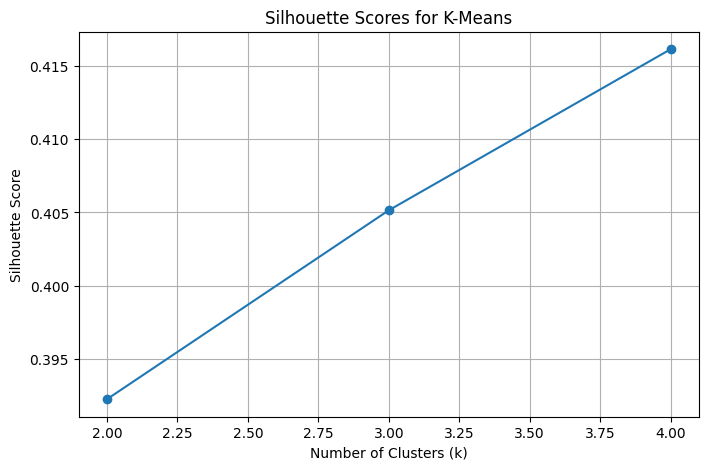

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


Step 4: Hierarchical Clustering (with Cosine Distance)

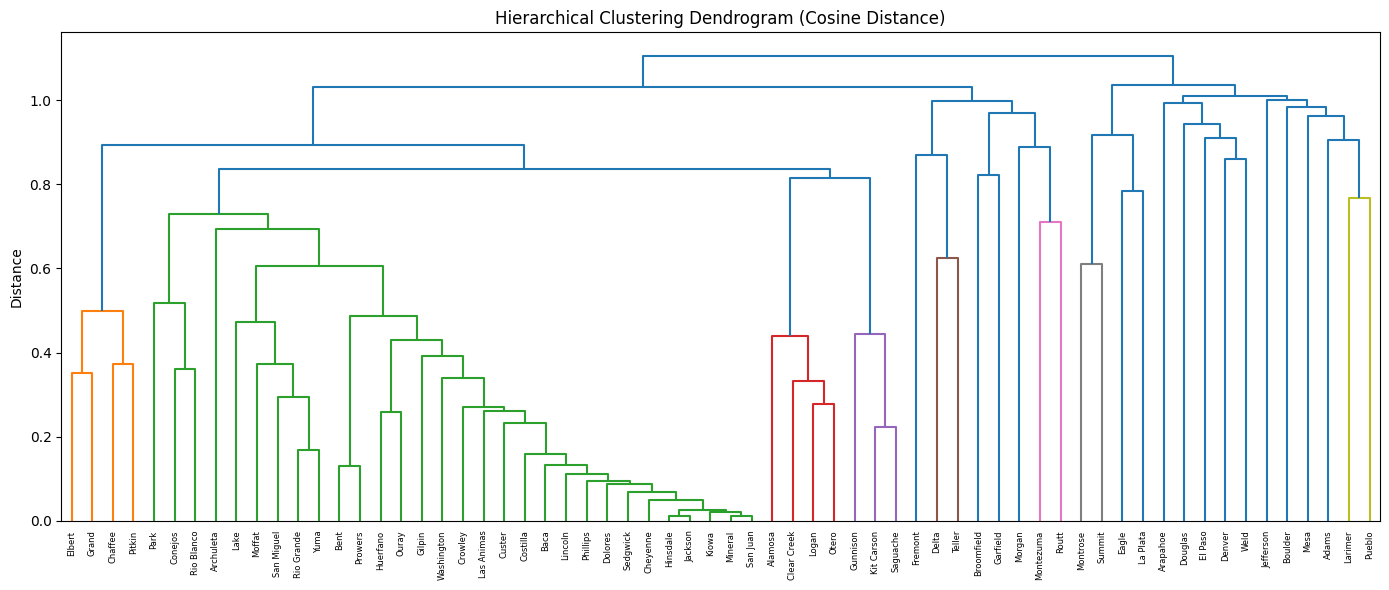

In [12]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Cosine distance matrix
cosine_dist = pdist(X_scaled, metric='cosine')

# Agglomerative clustering with average linkage
Z = linkage(cosine_dist, method='average')

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=pivot_df.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Cosine Distance)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Step 5: Assign Clusters from Hierarchical Clustering

In [13]:
hierarchical_labels = fcluster(Z, t=3, criterion='maxclust')

# Add both clustering results to the original pivot_df
pivot_df['kmeans_3'] = kmeans_models[3].labels_
pivot_df['hierarchical_3'] = hierarchical_labels
pivot_df.head()


age,0,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,100,kmeans_3,hierarchical_3
county,,,,,,,,,,,,,,,,,,,,,
Adams,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,3
Alamosa,0,177,0,0,0,0,0,0,200,0,...,0,0,0,0,0,0,0,0,1,1
Arapahoe,0,0,0,0,0,0,0,9574,0,0,...,0,0,0,0,0,0,0,0,1,3
Archuleta,0,0,0,0,124,134,141,0,153,0,...,0,0,0,0,0,0,0,0,1,1
Baca,0,0,0,0,0,0,0,0,0,34,...,0,0,9,7,0,0,0,0,1,1


**(d) Results**
To identify patterns in projected population structures across Colorado counties, both k-means clustering and hierarchical clustering was applied to age-based population projections for the year 2050.

K-Means clustering was applied using three different values of k (2, 3, and 4) to explore how Colorado counties group based on age-distributed population projections for 2050. The silhouette scores for each value of k were: 0.392 for k = 2, 0.405 for k = 3, and 0.416 for k = 4, indicating that four clusters yielded the most well-separated and coherent groupings. Silhouette scores measure how similar each data point is to its own cluster compared to others. Thus higher scores reflect better-defined clusters. Based on this analysis, k = 4 was selected as the optimal number of clusters to describe distinct population patterns across counties.

In addition to K-Means, hierarchical clustering using cosine distance and average linkage was performed to uncover how counties relate based on the shape of their age distribution curves. The resulting dendrogram reveals a tree-like structure showing how clusters form step-by-step, starting with the most similar counties. This method helps visualize the relative closeness of population age structures across the state. A comparison of cluster assignments from hierarchical clustering and K-Means (at k = 3) shows general agreement for many counties. For example, Alamosa, Archuleta, and Baca were consistently grouped together. However, some counties such as Adams and Arapahoe were assigned to different clusters depending on the method used. This divergence suggests that cosine similarity captures subtle differences in relative age proportions that may not be as pronounced when using Euclidean-based K-Means clustering.


**(e) Conclusion**

Through clustering analysis of Colorado's projected county-level population data for the year 2050, it was uncovered that distinct groupings of counties with similar age distributions. These clusters provide valuable insight into how future behavioral health service demand may vary across regions. For example, one group of counties may be characterized by a larger proportion of older adults, signaling an anticipated need for geriatric mental health services, while another cluster may reflect a younger demographic profile, indicating future demand for youth and adolescent behavioral health interventions.

The combination of K-Means clustering (with optimal k = 4) and hierarchical clustering (using cosine similarity) offered complementary perspectives on how these counties align in terms of population structure. These methods revealed that counties often group not just by total population, but by the shape of their age distribution a factor that can directly influence the type and volume of mental health services required in coming decades.

By identifying clusters of demographically similar counties, this work provides a foundation for regional planning, targeted outreach, and more accurate demand forecasting in behavioral health. These insights are essential for informing policy decisions and resource allocation strategies across the state.

